# Brain Tumor Detection – CNN from Scratch
This notebook builds and trains a custom CNN on the brain tumor dataset.

## Check the device that runs the model

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

## 1. Test Data Generator (unseen data)

In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    '../data/Testing',          # because notebook is inside 'notebooks/'
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

I0000 00:00:1778021256.368703  616876 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778021256.369597  616876 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778021256.413174  616876 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778021257.747502  616876 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Found 1600 images belonging to 4 classes.


## 2. Training & Validation Generators (from Training/ folder)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam 

# Common seed for reproducible split
SEED = 42

# Training generator with only horizontal flip (no rotation/shift/zoom)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    validation_split=0.2
)

# Validation generator – only rescale, no augmentation (uses subset='validation')
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2           # ← required for subset filtering
)

train_generator = train_datagen.flow_from_directory(
    '../data/Training',
    target_size=(128,128),
    batch_size=64,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

val_generator = val_datagen.flow_from_directory(
    '../data/Training',
    target_size=(128,128),
    batch_size=64,
    class_mode='categorical',
    subset='validation',
    seed=SEED
)

print("Training/validation generators ready (training uses augmentation)")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Training/validation generators ready (training uses augmentation)
Training samples: 4480
Validation samples: 1120


## 3. Compute custom class weights, as of now increase the weights for glioma

In [3]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get all true labels from the training generator (these are integers 0..3)
y_train = train_generator.classes

# Compute balanced class weights
# Manual class weights: boost glioma (class 0)
class_weight = {0: 1.5, 1: 1.0, 2: 1.0, 3: 1.0}
print("Class weights:", class_weight)

Class weights: {0: 1.5, 1: 1.0, 2: 1.0, 3: 1.0}


## 4. Build and Compile the CNN Model

In [4]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'      # Suppresses info/warning logs
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'     # Suppresses oneDNN custom operations message
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),   # half of default
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

/home/alexei/brain-tumor-detection-model/venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1778021259.089355  616876 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1778021259.089601  617007 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1778021259.107626  616876 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,517,060 (24.86 MB)

 Trainable params: 6,517,060 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Callbacks – Early Stopping and Model Checkpoint

In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os

os.makedirs('models', exist_ok=True)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('models/scratch_model.keras', monitor='val_accuracy', save_best_only=True)

## 6. Train the Model

In [6]:
import tensorflow as tf
tf.get_logger().setLevel('ERROR')

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[early_stop, checkpoint],
    verbose=1,
    class_weight=class_weight
)

Epoch 1/30


I0000 00:00:1778021259.632549  616876 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


70/70 ━━━━━━━━━━━━━━━━━━━━ 32s 434ms/step - accuracy: 0.5850 - loss: 1.0730 - val_accuracy: 0.6616 - val_loss: 0.8194
Epoch 2/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 31s 435ms/step - accuracy: 0.7386 - loss: 0.7247 - val_accuracy: 0.6982 - val_loss: 0.8061
Epoch 3/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 31s 441ms/step - accuracy: 0.7792 - loss: 0.6193 - val_accuracy: 0.7714 - val_loss: 0.5809
Epoch 4/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 30s 433ms/step - accuracy: 0.8031 - loss: 0.5587 - val_accuracy: 0.7661 - val_loss: 0.6095
Epoch 5/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 32s 453ms/step - accuracy: 0.8232 - loss: 0.5078 - val_accuracy: 0.8446 - val_loss: 0.3992
Epoch 6/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 45s 635ms/step - accuracy: 0.8268 - loss: 0.4790 - val_accuracy: 0.8321 - val_loss: 0.4019
Epoch 7/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 44s 625ms/step - accuracy: 0.8462 - loss: 0.4425 - val_accuracy: 0.8562 - val_loss: 0.3736
Epoch 8/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 43s 613ms/step - accuracy: 0.8545 - loss: 0.4138 - val_accuracy: 0.833

## 7. Evaluation on the Test Set

In [7]:
test_loss, test_acc = model.evaluate(test_generator, verbose=0)
print(f"Brain Scan CNN - Test accuracy: {test_acc:.4f}")

Brain Scan CNN - Test accuracy: 0.8781


## 8. Evaluate the Best Saved Model (Checkpoint)

In [8]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   # Suppresses all logs below ERROR
from tensorflow.keras.models import load_model
best = load_model('models/scratch_model.keras')
test_loss, test_acc = best.evaluate(test_generator, verbose=0)
print(f"Best checkpoint model test accuracy: {test_acc:.4f}")

Best checkpoint model test accuracy: 0.8781


## 9. Save Training History to JSON

In [9]:
import json
history_dict = {
    'accuracy': history.history['accuracy'],
    'val_accuracy': history.history['val_accuracy'],
    'loss': history.history['loss'],
    'val_loss': history.history['val_loss'],
    'best_val_acc': max(history.history['val_accuracy']),
    'best_test_acc': test_acc  # from above
}
with open('scratch_history.json', 'w') as f:
    json.dump(history_dict, f)

## 10. Visualise Training History (Accuracy & Loss)

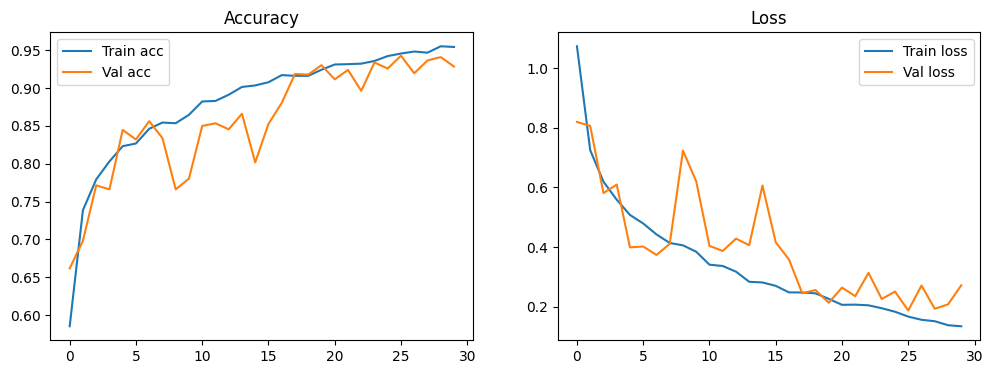

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train acc')
plt.plot(history.history['val_accuracy'], label='Val acc')
plt.title('Accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('Loss')
plt.legend()
plt.show()

## 11. Compare new to backed up model

In [11]:
from tensorflow.keras.models import load_model
backup_model = load_model('models/scratch_model_backup.keras')
new_model = load_model('models/scratch_model.keras')
print("Backup test accuracy:", backup_model.evaluate(test_generator, verbose=0)[1])
print("New model test accuracy:", new_model.evaluate(test_generator, verbose=0)[1])

Backup test accuracy: 0.871874988079071
New model test accuracy: 0.878125011920929


## 12. Compare the weight differences to affirm the models are different

In [12]:
import numpy as np
diff = np.max(np.abs(backup_model.get_weights()[0] - new_model.get_weights()[0]))
print(f"Maximum weight difference: {diff}")

Maximum weight difference: 0.3716910481452942


## 13. Generate a confusion matrix, classification report

In [13]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Get predictions
y_pred = best.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# Report
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# Confusion matrix
print(confusion_matrix(y_true, y_pred_classes))

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step
              precision    recall  f1-score   support

      glioma       0.97      0.69      0.81       400
  meningioma       0.83      0.84      0.83       400
     notumor       0.80      1.00      0.89       400
   pituitary       0.96      0.98      0.97       400

    accuracy                           0.88      1600
   macro avg       0.89      0.88      0.88      1600
weighted avg       0.89      0.88      0.88      1600

[[275  67  51   7]
 [  7 337  48   8]
 [  0   0 400   0]
 [  1   4   2 393]]


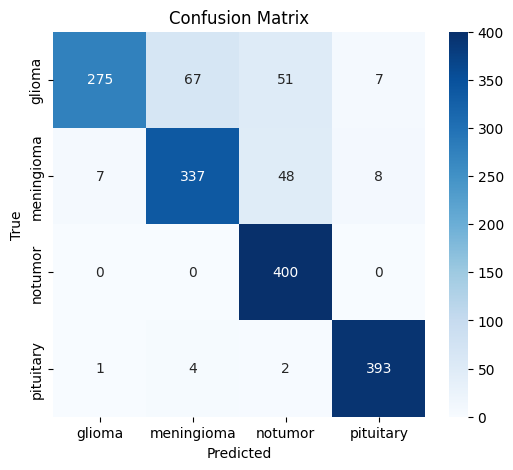

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## 14. Backup the last produced model

In [15]:
import shutil
import os

# Paths (assuming notebook is in notebooks/ folder)
src = 'models/scratch_model.keras'
dst = 'models/scratch_model_backup.keras'

if os.path.exists(src):
    shutil.copy(src, dst)
    print(f"Backed up {src} to {dst}")
else:
    print(f"Source file {src} not found. Nothing copied.")

Backed up models/scratch_model.keras to models/scratch_model_backup.keras
